# FOV Finder Agent — feature-based filtering with `FOVCondition`

Extends the simple `fov_finder_demo.ipynb` to filter candidate FOVs by **per-cell features** extracted during scanning — not just cell count.

Pipeline per phase:

1. Load plate calibration (`WellPlatePlan`).
2. Generate random candidate positions inside each well.
3. Image each candidate (multi-channel, including the biosensor channel).
4. Segment the nuclear channel to count cells — reject candidates below `min_cells`.
5. On remaining candidates, run `FeatureExtractor.extract_features(labels, img_stack)` to compute per-cell features (e.g. `cnr` from `FE_ErkKtr`).
6. Apply every `FOVCondition` — reject FOVs where fewer than `min_fraction` of cells satisfy the threshold.
7. Farthest-point sample the surviving candidates.

Example condition:

```python
FOVCondition(feature="cnr", operator="below", threshold=0.6, min_fraction=0.8)
# "accept FOV only if ≥80% of cells have cnr < 0.6"
```

Operators: `"below"`, `"above"`, `"below_or_equal"`, `"above_or_equal"`, `"equal"`.

## 1. Microscope and channel setup

Two imaging channels this time — one for the nuclear marker (segmentation) and one for the ERK-KTR biosensor (CNR).

In [1]:
from faro.microscope.pertzlab.jungfrau import Jungfrau
from faro.core.data_structures import PowerChannel

mic = Jungfrau()
mic.mmc.setChannelGroup("TTL_ERK")

imaging_channels = (
    PowerChannel(
        config="miRFP", exposure=125, group="TTL_ERK", power=95
    ),  # nuclear marker – segment on this
    PowerChannel(
        config="mScarlet3", exposure=125, group="TTL_ERK", power=95
    ),  # ERK-KTR biosensor – CNR computed on this
)

In [2]:
# If you don't need a GUI, you can just enabling hardware autofocus and go ahead
mic.mmc.setProperty(
    "TIPFSStatus", "State", "On"
)  # Assume focus has already been set; turn on PFS

# with this code, you start the GUI
# from napari_micromanager import MainWindow
# import napari

# viewer = napari.Viewer()
# mm_wdg = MainWindow(viewer)
# mm_wdg._mmc = mic.mmc  # point the widget at our CMMCore instance
# viewer.window.add_dock_widget(mm_wdg)  # dock Micro-Manager controls in napari

## 2. Plate calibration

In [3]:
PLATE_CALIBRATION_PATH = "./calib_plate_96.json"

from useq import WellPlatePlan

plan = WellPlatePlan.from_file(PLATE_CALIBRATION_PATH)
print(f"plate: {plan.plate.name}  rows={plan.plate.rows}  cols={plan.plate.columns}")
print(f"well_size mm: {plan.plate.well_size}  circular: {plan.plate.circular_wells}")

plate: 96-well  rows=8  cols=12
well_size mm: (6.4, 6.4)  circular: True


## 3. Segmentator

## 4. Feature extractor + FOV conditions

`FE_ErkKtr` builds a cytosolic ring around each nucleus and computes per-cell `cnr = mean(ring) / mean(nucleus)` on channel C1 (the ERK-KTR channel).

`FOVCondition` is evaluated *per FOV* on the per-cell feature table:

- `feature`: column name (e.g. `"cnr"`, `"area_nuc"`).
- `operator`: one of `"below"`, `"above"`, `"below_or_equal"`, `"above_or_equal"`, `"equal"`.
- `threshold`: value to compare against.
- `min_fraction`: fraction of cells (0–1) that must satisfy the condition. Default `1.0` = all cells.

Multiple conditions are AND-combined.

In [ ]:
from faro.feature_extraction.erk_ktr import FE_ErkKtr
from faro.agents import FOVCondition

from faro.segmentation.cellpose_v4 import CellposeV4

segmentator = CellposeV4(min_size=200)
feature_extractor = FE_ErkKtr(
    used_mask="labels"
)  # use the "labels" mask from the segmentator to compute features on each cell

# Accept an FOV only if at least 80% of its cells have CNR < 0.85
# (i.e. ERK is mostly nuclear -> biosensor in the "low ERK" regime).
fov_conditions = [
    FOVCondition(feature="cnr", operator="below", threshold=1, min_fraction=0.8),
    # Add more to AND-combine, e.g. reject FOVs with very small nuclei:
    # FOVCondition(feature="area_nuc", operator="above", threshold=650, min_fraction=0.7),
]

## 5. Configure the FOV finder

The only differences from the simple demo are:

- Two imaging channels (the biosensor channel is needed for CNR).
- `feature_extractor=FE_ErkKtr(...)` — without this the conditions have nothing to evaluate.
- `fov_conditions=[...]` — the new filter.
- `strict_count=False` — don't pad with invalid candidates; we want to see which candidates are rejected.

Per FOV, the agent stashes:
- `all_candidates` row with columns `fe_cnr_mean`, `fe_cnr_median`, `cond_cnr_below_frac`, `valid`, `reason`.
- The full per-cell DataFrame in `last_run["fov_features"][p]`.

[FOVFinderAgent] Phase 0: scanning 10 candidates in 2 wells: ['E8', 'D8']


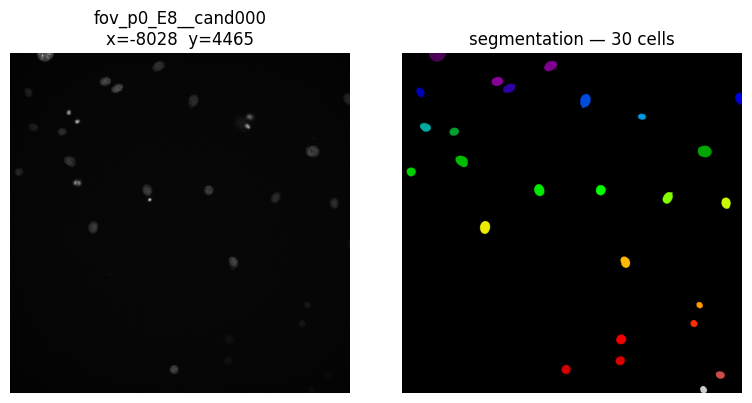

C:\Users\Jungfrau\Documents\alandolt\code\faro\faro\segmentation\cellpose_v4.py:42: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


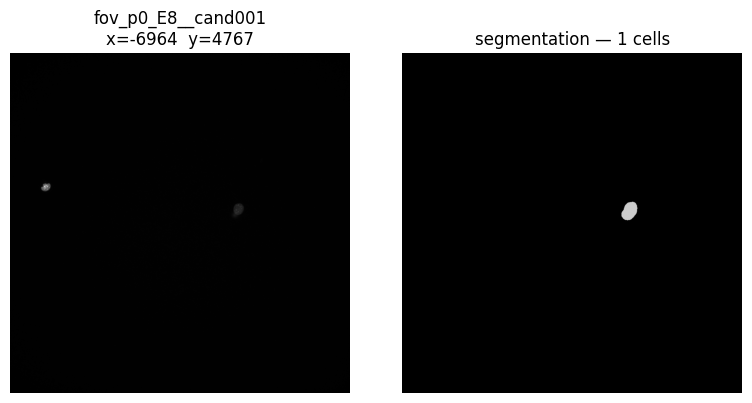

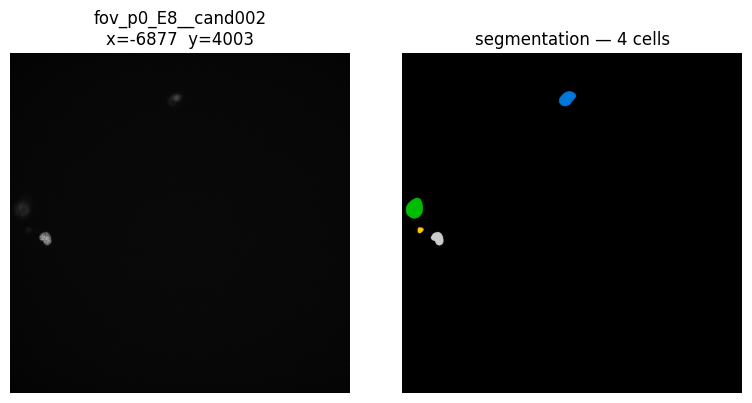

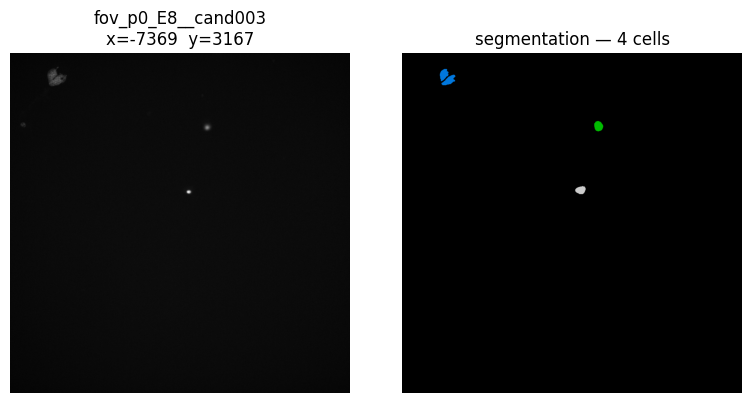

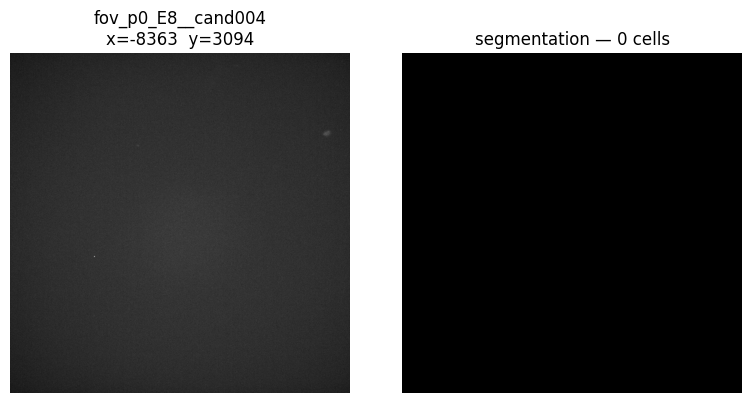

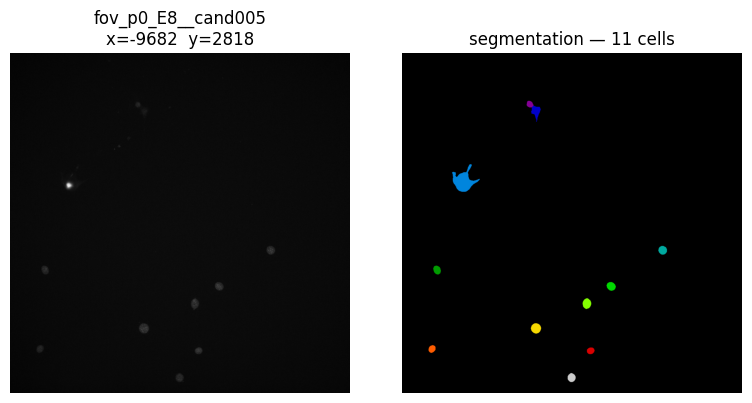

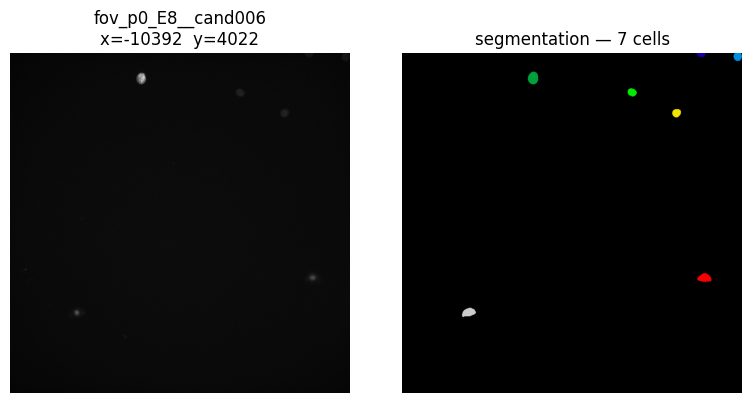

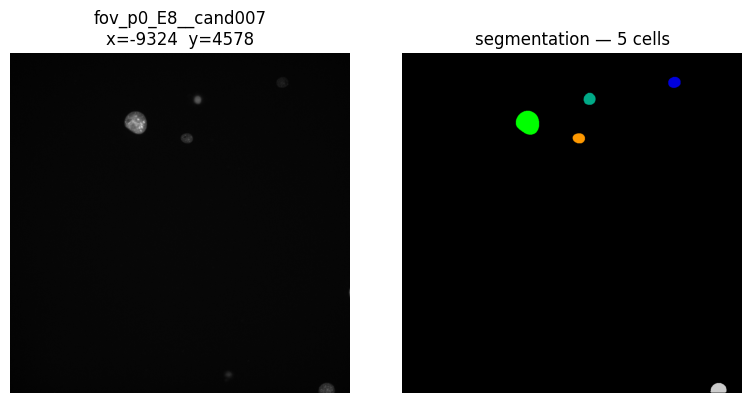

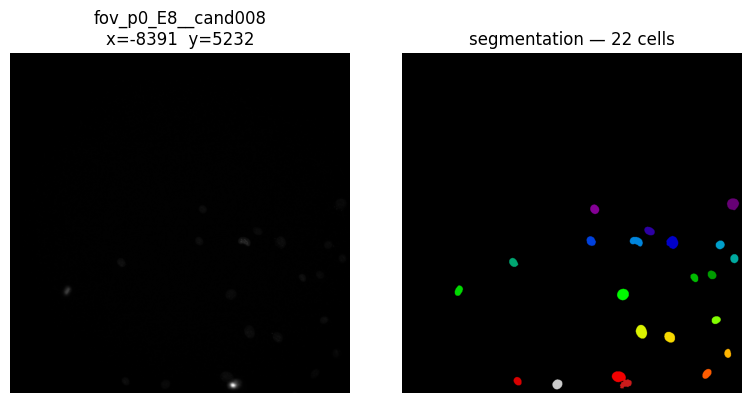

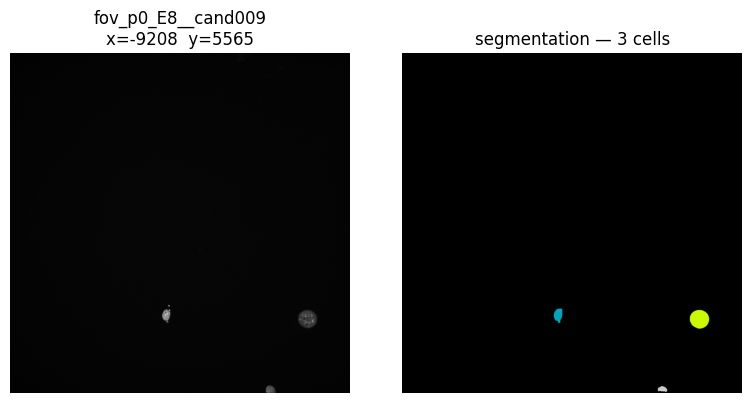

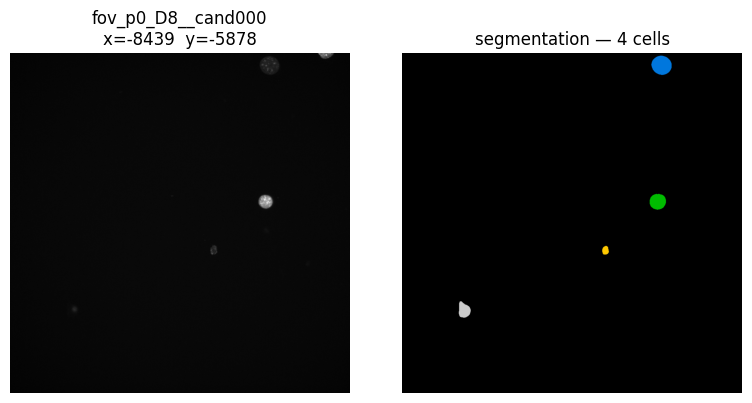

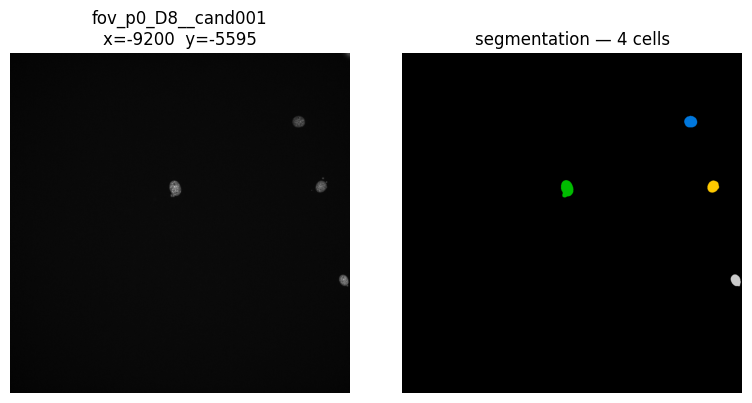

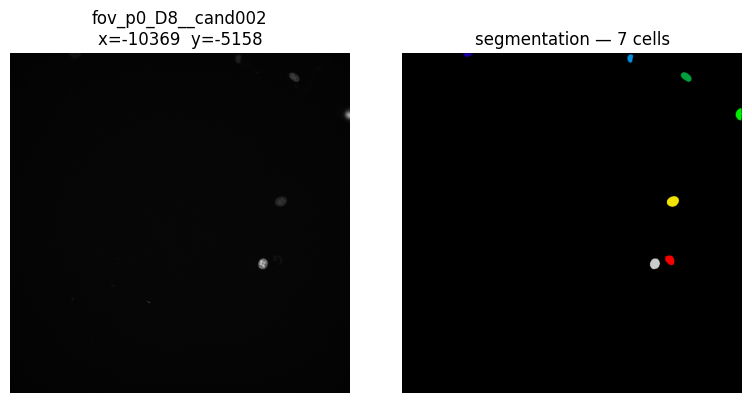

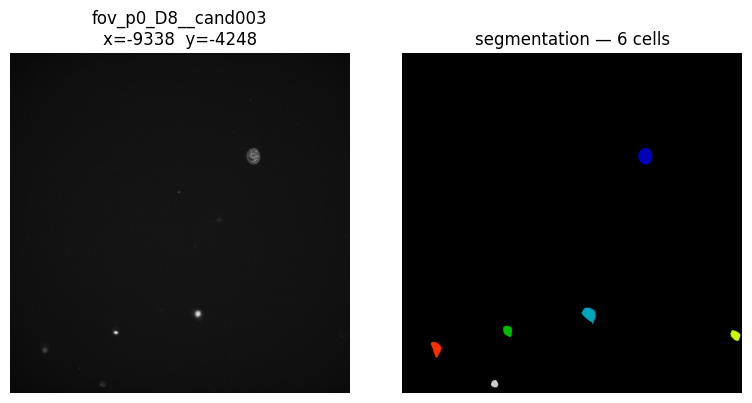

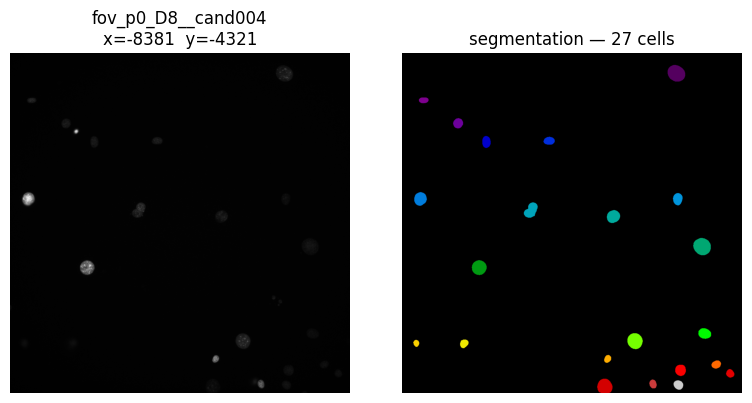

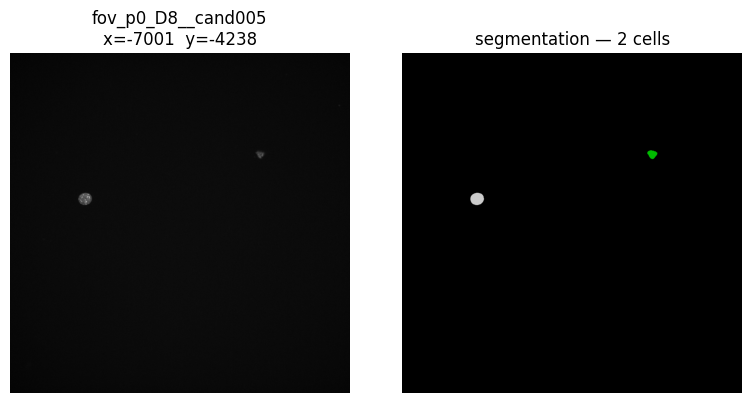

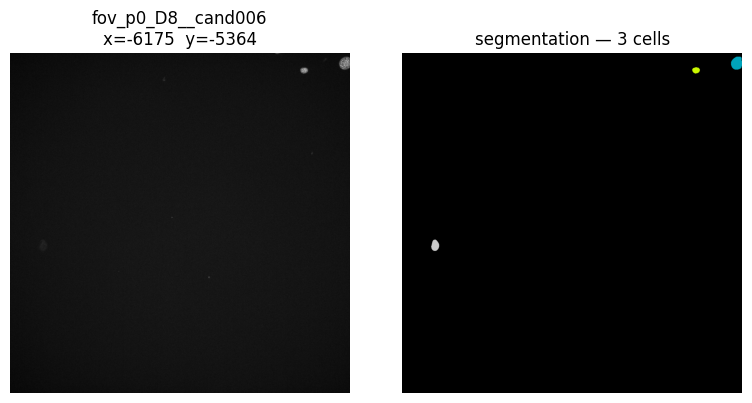

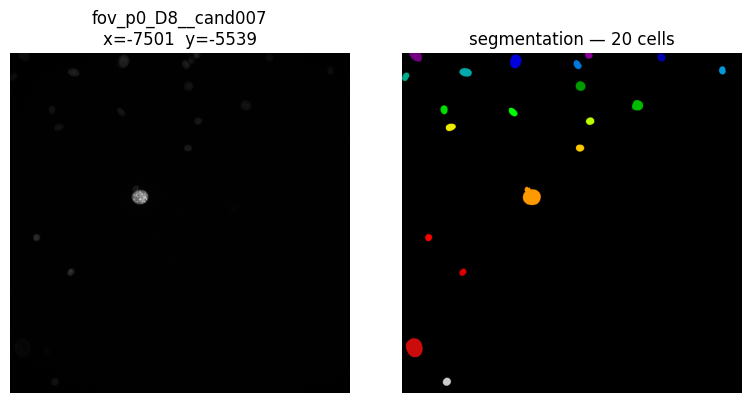

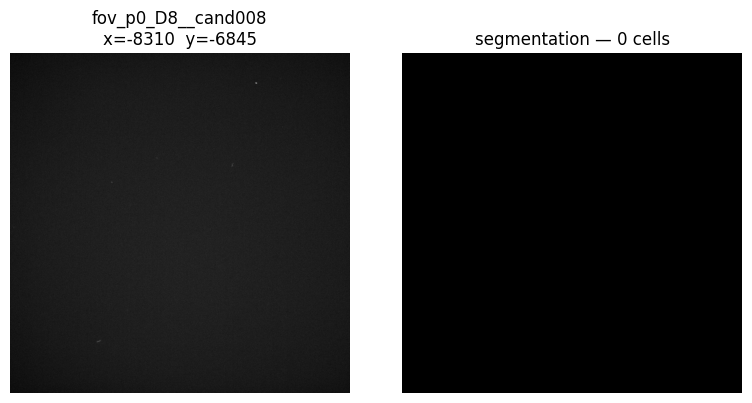

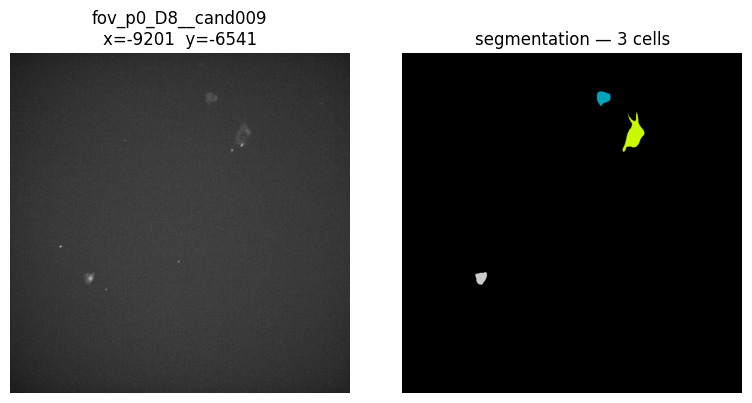

[FOVFinderAgent] WARNING: well E8 has no valid positions (need >= 10 cells); skipping.
[FOVFinderAgent] WARNING: well D8 has no valid positions (need >= 10 cells); skipping.


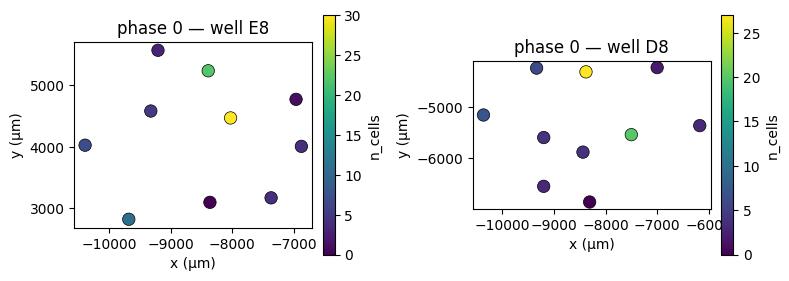

[FOVFinderAgent] Phase 0: selected 0 FOVs across 2 wells (median valid candidates/well: 0).

Selected 0 FOVs after cell-count + CNR filtering.


In [17]:
from faro.agents import FOVFinderAgent

finder = FOVFinderAgent(
    microscope=mic,
    well_plate_plan=PLATE_CALIBRATION_PATH,
    wells=["E8", "D8"],
    fovs_per_well=3,
    n_candidates_per_well=10,
    border_um=1000.0,
    min_distance_um=750.0,
    min_cells=10,
    imaging_channels=imaging_channels,
    segmentator=segmentator,
    seg_channel_index=0,  # segment nuclei on miRFP (channel 0)
    feature_extractor=feature_extractor,
    fov_conditions=fov_conditions,
    z=None,  # don't use a Z, as we're relying on hardware autofocus to keep us in focus
    random_seed=123,
    strict_count=False,  # surface rejected candidates rather than padding them back in
    verbose=True,
)

selected = finder.run()
print(f"\nSelected {len(selected)} FOVs after cell-count + CNR filtering.")

## 6. Inspect the filtering

`all_candidates` carries the per-FOV summary and `last_run["fov_features"]` holds the full per-cell tables.

In [15]:
df

,p,x,y,z,n_cells,valid,reason,n_cells_features,fe_mean_intensity_C0_nuc_mean,fe_mean_intensity_C0_nuc_median,...,fe_median_intensity_C1_ring_median,fe_cnr_mean,fe_cnr_median,fe_cnr_median_mean,fe_cnr_median_median,cond_cnr_below_frac,cond_area_nuc_above_frac,fe_x_mean,fe_y_mean,well
0,0,9972.069049,4505.929113,None,47,False,condition_failed:area_nuc_above_700@0.90,45.0,1386.973311,1038.664957,...,1248.00,0.732119,0.717689,0.727568,0.744244,0.933333,0.511111,NaN,NaN,E6
1,1,11036.095912,4808.250658,None,15,False,condition_failed:cnr_below_1@0.80,15.0,715.465227,662.809633,...,1524.00,0.889318,0.957671,0.900517,0.965737,0.733333,NaN,NaN,NaN,E6
2,2,11122.863512,4044.082099,None,19,False,condition_failed:area_nuc_above_700@0.90,18.0,1298.189150,1059.455349,...,1933.25,0.746974,0.759888,0.756848,0.786569,0.833333,0.222222,NaN,NaN,E6
3,3,10630.827461,3207.544196,None,30,False,condition_failed:cnr_below_1@0.80,25.0,933.183040,802.628466,...,1050.00,0.809227,0.796952,0.808530,0.795455,0.680000,NaN,NaN,NaN,E6
4,4,9636.767964,3134.609406,None,62,False,condition_failed:cnr_below_1@0.80,58.0,1090.801513,1002.492524,...,1228.50,0.821144,0.837467,0.824144,0.829167,0.758621,NaN,NaN,NaN,E6
5,5,8317.789539,2859.265530,None,16,False,condition_failed:area_nuc_above_700@0.90,14.0,870.054470,797.224799,...,1490.50,0.654651,0.540010,0.661816,0.536572,0.928571,0.000000,NaN,NaN,E6
6,6,7607.781975,4063.144215,None,16,False,condition_failed:cnr_below_1@0.80,14.0,713.071009,617.367442,...,1065.00,0.853656,0.905992,0.867584,0.905462,0.642857,NaN,NaN,NaN,E6
7,7,8675.928437,4618.387828,None,43,False,condition_failed:area_nuc_above_700@0.90,41.0,1025.084576,967.951442,...,1346.00,0.625943,0.595236,0.623376,0.575000,0.926829,0.243902,NaN,NaN,E6
8,8,9608.978613,5272.612102,None,58,False,condition_failed:area_nuc_above_700@0.90,54.0,1412.568936,1358.675996,...,1590.50,0.730769,0.744951,0.720897,0.722367,0.851852,0.314815,NaN,NaN,E6
9,9,8792.404138,5605.598338,None,1,False,below_min_cells,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,573.738164,131.392271,E6


In [14]:
df = finder.last_run["all_candidates"]
display_cols = [
    "p",
    "well",
    "n_cells",
    "fe_cnr_mean",
    "fe_cnr_median",
    "cond_cnr_below_frac",
    "valid",
    "area_nuc",
    "reason",
]
df[[c for c in display_cols if c in df.columns]]

,p,well,n_cells,fe_cnr_mean,fe_cnr_median,cond_cnr_below_frac,valid,reason
0,0,E6,47,0.732119,0.717689,0.933333,False,condition_failed:area_nuc_above_700@0.90
1,1,E6,15,0.889318,0.957671,0.733333,False,condition_failed:cnr_below_1@0.80
2,2,E6,19,0.746974,0.759888,0.833333,False,condition_failed:area_nuc_above_700@0.90
3,3,E6,30,0.809227,0.796952,0.680000,False,condition_failed:cnr_below_1@0.80
4,4,E6,62,0.821144,0.837467,0.758621,False,condition_failed:cnr_below_1@0.80
5,5,E6,16,0.654651,0.540010,0.928571,False,condition_failed:area_nuc_above_700@0.90
6,6,E6,16,0.853656,0.905992,0.642857,False,condition_failed:cnr_below_1@0.80
7,7,E6,43,0.625943,0.595236,0.926829,False,condition_failed:area_nuc_above_700@0.90
8,8,E6,58,0.730769,0.744951,0.851852,False,condition_failed:area_nuc_above_700@0.90
9,9,E6,1,NaN,NaN,NaN,False,below_min_cells


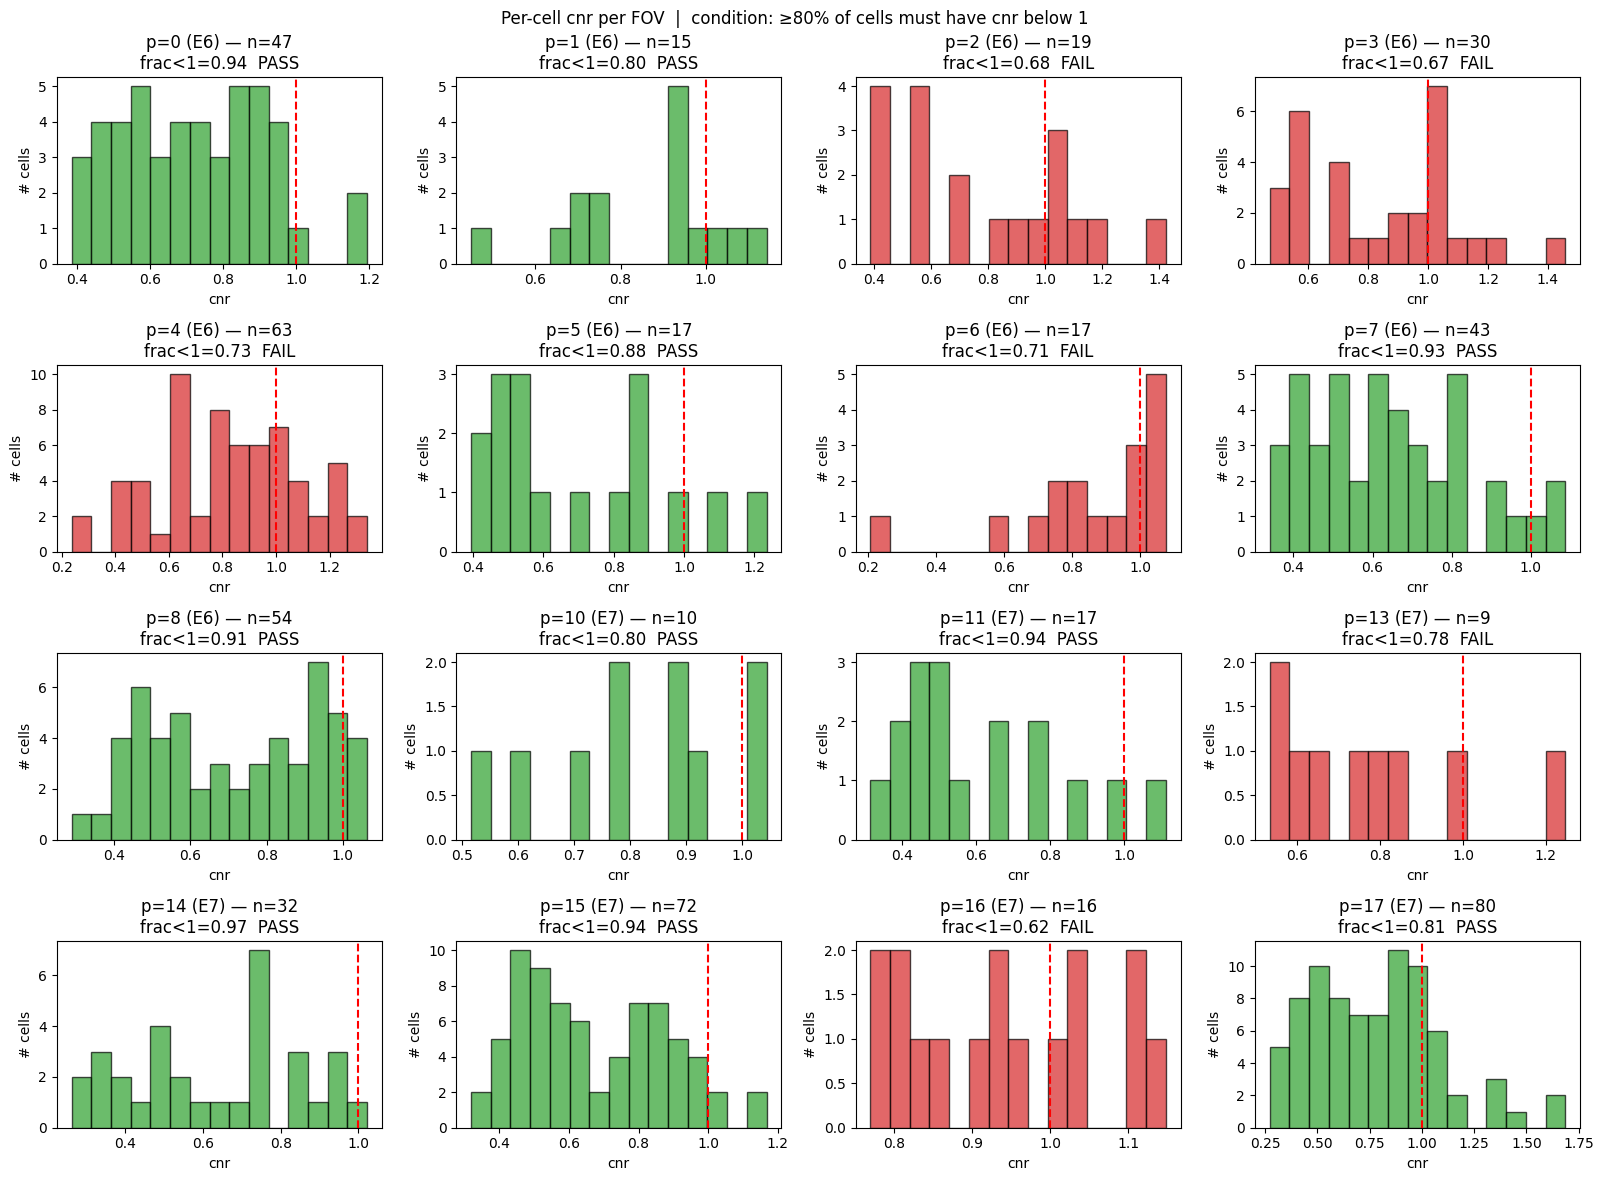

In [8]:
# Per-cell CNR distribution for every scanned FOV that had features computed.
# Red dashed line = threshold; green histograms = FOV passes the condition, red = fails.
import matplotlib.pyplot as plt

fov_features = finder.last_run["fov_features"]
df_scan = finder.last_run["all_candidates"]
cond = fov_conditions[0]
n = len(fov_features)

if n == 0:
    print("No FOV had features computed (no candidate passed the cell-count filter).")
else:
    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False
    )
    for ax, (p_idx, df_cells) in zip(axes.flat, sorted(fov_features.items())):
        row = df_scan[df_scan["p"] == p_idx].iloc[0]
        passed = bool(row["valid"])
        frac = row.get(f"cond_{cond.feature}_{cond.operator}_frac", float("nan"))
        color = "tab:green" if passed else "tab:red"
        ax.hist(
            df_cells[cond.feature].dropna(),
            bins=15,
            color=color,
            alpha=0.7,
            edgecolor="k",
        )
        ax.axvline(cond.threshold, color="red", ls="--", label=f"thr={cond.threshold}")
        ax.set_title(
            f"p={p_idx} ({row['well']}) — n={len(df_cells)}\n"
            f"frac<{cond.threshold}={frac:.2f}  {'PASS' if passed else 'FAIL'}"
        )
        ax.set_xlabel(cond.feature)
        ax.set_ylabel("# cells")
    for ax in axes.flat[n:]:
        ax.axis("off")
    fig.suptitle(
        f"Per-cell {cond.feature} per FOV  |  condition: "
        f"≥{cond.min_fraction:.0%} of cells must have {cond.feature} "
        f"{cond.operator} {cond.threshold}"
    )
    plt.tight_layout()
    plt.show()

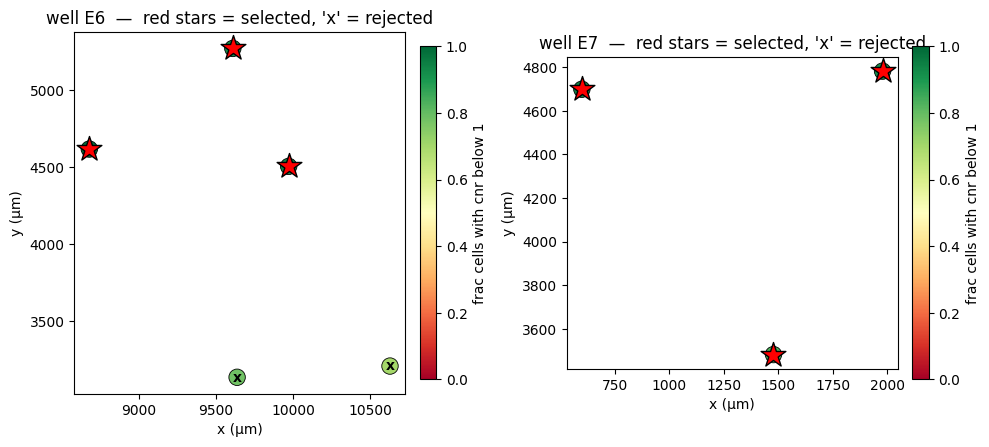

In [23]:
# Stage-plane scatter of all candidates per well, coloured by CNR fraction,
# with selected (passing + FPS-picked) FOVs highlighted as red crosses.
import matplotlib.pyplot as plt

frac_col = f"cond_{cond.feature}_{cond.operator}_frac"
wells_used = finder.last_run["wells_used"]
selected_by_well = {}
for fp, w in zip(finder.last_run["positions"], finder.last_run["wells_for_positions"]):
    selected_by_well.setdefault(w, []).append(fp)

fig, axes = plt.subplots(
    1, len(wells_used), figsize=(5 * len(wells_used), 5), squeeze=False
)
for ax, well in zip(axes[0], wells_used):
    df_w = df_scan[df_scan["well"] == well]
    sc = ax.scatter(
        df_w["x"],
        df_w["y"],
        c=df_w.get(frac_col, df_w["n_cells"]),
        cmap="RdYlGn",
        vmin=0,
        vmax=1,
        s=140,
        edgecolors="k",
        linewidths=0.6,
    )
    for _, row in df_w[~df_w["valid"]].iterrows():
        ax.annotate(
            "x",
            (row["x"], row["y"]),
            ha="center",
            va="center",
            color="black",
            fontsize=10,
            fontweight="bold",
        )
    for fp in selected_by_well.get(well, []):
        ax.scatter(
            [fp.x],
            [fp.y],
            marker="*",
            c="red",
            s=350,
            edgecolors="k",
            linewidths=1,
            zorder=5,
        )
    ax.set_title(f"well {well}  \u2014  red stars = selected, 'x' = rejected")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_aspect("equal")
    fig.colorbar(
        sc,
        ax=ax,
        fraction=0.046,
        pad=0.04,
        label=f"frac cells with {cond.feature} {cond.operator} {cond.threshold}",
    )
plt.tight_layout()
plt.show()